# S2 Human Study Results
Reads all `experiment/s2_humans/*.json`, merges participants, filters incomplete (< 300 answers).

In [322]:
import re
import json, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from collections import defaultdict

BASE = Path('/home/david/Desktop/yuna/HPA')
sys.path.insert(0, str(BASE / 'analysis'))  # must come before utils imports

from utils.normalize_korean import normalize_korean_answer
from utils.vqa import VQAAnswerMapper, vqa_accuracy
mapper = VQAAnswerMapper()

sns.set_theme(style='whitegrid', font_scale=1.1)
VARIANT_ORDER = ['C', 'B', 'A']
VARIANT_LABELS = {'C': 'C (original)', 'B': 'B (weaker obj)', 'A': 'A (pronominalized)'}
VARIANT_COLORS = {'C': '#2196F3', 'B': '#FF9800', 'A': '#E91E63'}


import re as _re
def _clean_answer(ans):
    """Strip <think>...</think> CoT prefix (Qwen3 backbone)."""
    return _re.sub(r'<think>.*?</think>\s*', '', ans, flags=_re.DOTALL).strip()


In [323]:
# ── Load participants ────────────────────────────────────────────────────────
from utils.load_human import load_participants, flatten_to_df

participants = load_participants(BASE, min_answers=300)
print(f'Valid participants (>=300 answers): {len(participants)}')
for p in sorted(participants, key=lambda x: x['code']):
    print(f"  {p['code']}  tag={p['tag']}  answers={len(p['answers'])}  status={p['session_status']}")

Valid participants (>=300 answers): 10
  8HLCRUY1  tag=19일  answers=348  status=session_3_completed
  DPCN9S37  tag=19일  answers=348  status=session_3_completed
  FLWP3ZF7  tag=19일  answers=348  status=session_3_completed
  HB857QDA  tag=exp  answers=348  status=session_3_completed
  J09HHJXK  tag=19일  answers=348  status=session_3_completed
  K8VD3TYB  tag=19일  answers=348  status=session_3_completed
  MPOMQQNU  tag=19일  answers=348  status=session_3_completed
  NVF556XP  tag=19일  answers=348  status=session_3_completed
  Q4PLE2BH  tag=19일  answers=348  status=session_3_completed
  ZEF2XJBX  tag=19일  answers=348  status=session_3_completed


In [210]:
# ── Flatten to DataFrame ──────────────────────────────────────────────────────
from utils.normalize_korean import normalize_korean_answer

s2 = pd.read_csv(BASE / "experiment/s2_v2/s2.csv")[[
    "question_id","ent","op","ent_grp","op_grp","signal_score","acc_original"
]]
df = flatten_to_df(participants, mapper, s2, normalize_fn=normalize_korean_answer)

import re as _re
kr_char = _re.compile(r"[가-힣]")
df["normalized"] = ~df["answer_en"].apply(lambda x: bool(kr_char.search(str(x))))
n_unnorm = (~df["normalized"]).sum()
print(f"Rows: {len(df)} | questions: {df.question_id.nunique()} | participants: {df.participant.nunique()}")
print(f"Answers still in Korean (scored 0): {n_unnorm} / {len(df)} ({100*n_unnorm/len(df):.1f}%)")
df.head(3)[["participant","variant","answer_kr","answer_en","gt","accuracy","normalized"]]

   Loading VQA annotations from /home/david/Desktop/yuna/data/v2_mscoco_val2014_annotations.json...
   ✓ Loaded 214354 VQA annotations
Rows: 3132 | questions: 116 | participants: 9
Answers still in Korean (scored 0): 0 / 3132 (0.0%)


,participant,variant,answer_kr,answer_en,gt,accuracy,normalized
0,DPCN9S37,A,0명,0,"[3, 2, 2, 2, 3, 2, 2, 1, 2, 1]",0.0,True
1,DPCN9S37,A,아뇨,no,"[maybe, yes, yes, yes, yes, no, no, no, maybe,...",1.0,True
2,DPCN9S37,A,모르는데요,unknown,"[30, 200, 34, 125, 44, 100, which on as they a...",0.0,True


## 1. Overview — Accuracy by Variant

   Loading VQA annotations from /home/david/Desktop/yuna/data/v2_mscoco_val2014_annotations.json...
   ✓ Loaded 214354 VQA annotations


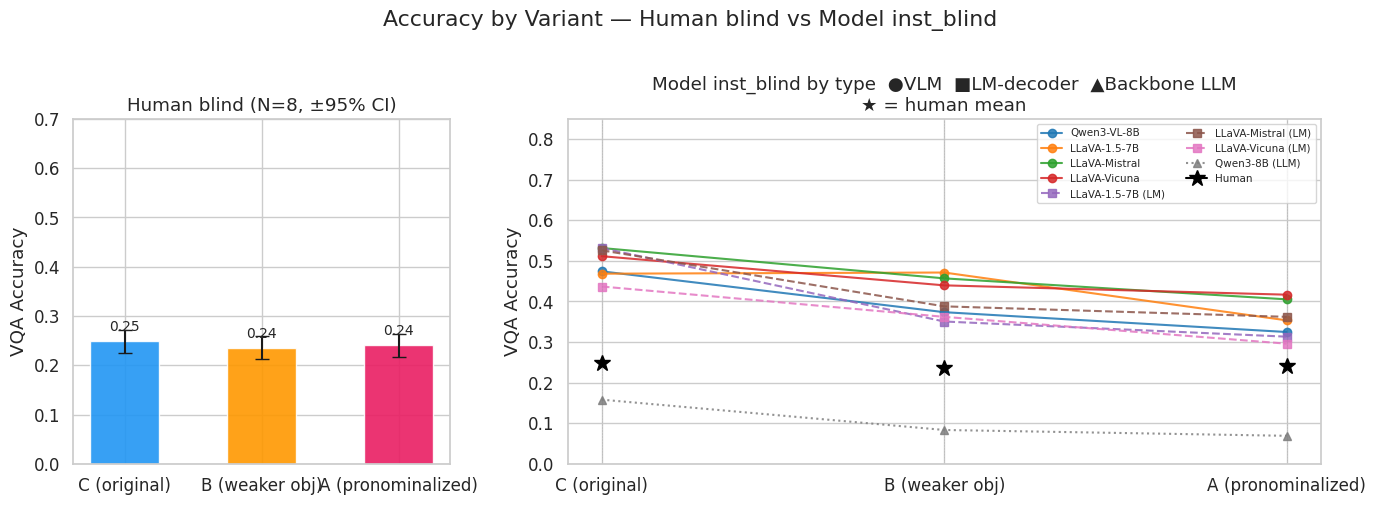

In [324]:
# Accuracy by variant — human (blind) + all model types (inst_blind)
# Three model types differentiated by marker:
#   VLM (pretrained)   : solid line, circle marker
#   LM-decoder         : dashed line, square marker  (VLM backbone extracted as LM)
#   Backbone LLM       : dotted line, triangle marker (standalone LLM, no vision)
from collections import defaultdict

_CT      = {'question': 'C', 'weaker_object': 'B', 'pronominalized': 'A'}
_q_ids   = set(df['question_id'].tolist())
_RESULTS = BASE / 'evaluation/logits'

MODEL_GROUPS = {
    'vlm': {
        'dir': _RESULTS / 'pretrained',
        'models': {
            'Qwen3-VL-8B':   'Qwen3-VL-8B-Instruct',
            'LLaVA-1.5-7B':  'llava-1.5-7b-hf',
            'LLaVA-Mistral': 'llava-v1.6-mistral-7b-hf',
            'LLaVA-Vicuna':  'llava-v1.6-vicuna-7b-hf',
        },
        'linestyle': '-',  'marker': 'o', 'label_suffix': '(VLM)',
    },
    'lm_decoder': {
        'dir': _RESULTS / 'lm_decoder/pretrained',
        'models': {
            'LLaVA-1.5-7B\n(LM)':  'llava-1.5-7b-hf',
            'LLaVA-Mistral\n(LM)': 'llava-v1.6-mistral-7b-hf',
            'LLaVA-Vicuna\n(LM)':  'llava-v1.6-vicuna-7b-hf',
        },
        'linestyle': '--', 'marker': 's', 'label_suffix': '(LM-dec)',
    },
    'backbone': {
        'dir': _RESULTS / 'backbone/pretrained',
        'models': {
            'Qwen3-8B\n(LLM)': 'Qwen3-8B',
        },
        'linestyle': ':', 'marker': '^', 'label_suffix': '(LLM)',
    },
}

# Load per-variant means for all models
_acc = {}  # (group, label) → {var: mean_acc}
for gname, ginfo in MODEL_GROUPS.items():
    for label, mdir in ginfo['models'].items():
        path = ginfo['dir'] / mdir / 'vqa_1k_control_inst_blind.jsonl'
        if not path.exists(): continue
        raw = defaultdict(list)
        for line in open(path):
            ex = json.loads(line)
            qid = int(ex['question_id'])
            if qid not in _q_ids: continue
            gt = mapper.get_answers(qid)
            ga = ex.get('generated_answers', {})
            for ct, var in _CT.items():
                ans = _clean_answer(ga.get(ct, ''))
                if ans and gt:
                    raw[var].append(vqa_accuracy(ans, gt))
        _acc[(gname, label)] = {var: float(np.mean(v)) if v else np.nan
                                 for var, v in raw.items()}

# Human stats
acc_var = df.groupby('variant')['accuracy'].agg(['mean','sem']).loc[VARIANT_ORDER]

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5), gridspec_kw={'width_ratios': [1, 2]})

# Left: human bar chart with CI
ax = axes[0]
bars = ax.bar(
    [VARIANT_LABELS[v] for v in VARIANT_ORDER],
    acc_var['mean'], yerr=acc_var['sem'] * 1.96,
    color=[VARIANT_COLORS[v] for v in VARIANT_ORDER],
    capsize=5, width=0.5, edgecolor='white', alpha=0.9
)
for bar, (_, row) in zip(bars, acc_var.iterrows()):
    ax.text(bar.get_x() + bar.get_width() / 2, row['mean'] + 0.015,
            f"{row['mean']:.2f}", ha='center', va='bottom', fontsize=10)
ax.set_ylabel('VQA Accuracy')
ax.set_title('Human blind (N=8, ±95% CI)')
ax.set_ylim(0, 0.7)

# Right: line plot for all model types
ax = axes[1]
x_pos  = np.arange(len(VARIANT_ORDER))
cmap   = plt.get_cmap('tab10')
color_idx = 0
color_map = {}

for gname, ginfo in MODEL_GROUPS.items():
    ls = ginfo['linestyle']
    mk = ginfo['marker']
    for label, mdir in ginfo['models'].items():
        key = (gname, label)
        if key not in _acc: continue
        means = [_acc[key].get(var, np.nan) for var in VARIANT_ORDER]
        if all(np.isnan(m) for m in means): continue
        short = label.replace('\n', ' ')
        color = cmap(color_idx % 10)
        color_map[short] = color
        ax.plot(x_pos, means, linestyle=ls, marker=mk, color=color,
                label=short, linewidth=1.5, markersize=6, alpha=0.85)
        color_idx += 1

# Human mean as horizontal reference lines per variant
for i, var in enumerate(VARIANT_ORDER):
    ax.axvline(i, color='gray', lw=0.4, ls='--', alpha=0.3)
    ax.plot(i, acc_var.loc[var, 'mean'], marker='*', markersize=12,
            color='black', zorder=5,
            label='Human' if i == 0 else '_nolegend_')

ax.set_xticks(x_pos)
ax.set_xticklabels([VARIANT_LABELS[v] for v in VARIANT_ORDER])
ax.set_ylabel('VQA Accuracy')
ax.set_title('Model inst_blind by type  ●VLM  ■LM-decoder  ▲Backbone LLM\n★ = human mean')
ax.set_ylim(0, 0.85)
ax.legend(fontsize=7.5, ncol=2, loc='upper right', framealpha=0.8)

plt.suptitle('Accuracy by Variant — Human blind vs Model inst_blind', y=1.01)
plt.tight_layout()
plt.show()


In [325]:
# Per-participant accuracy by variant
pp = df.groupby(['participant','variant'])['accuracy'].mean().unstack()[VARIANT_ORDER]
print('Per-participant accuracy:')
print(pp.round(3))
print(f'\nMean degradation C→A: {(pp["C"] - pp["A"]).mean():.3f}')

Per-participant accuracy:
variant          C      B      A
participant                     
8HLCRUY1     0.273  0.279  0.250
DPCN9S37     0.247  0.170  0.195
FLWP3ZF7     0.230  0.210  0.261
HB857QDA     0.244  0.305  0.239
J09HHJXK     0.239  0.236  0.244
K8VD3TYB     0.204  0.236  0.250
MPOMQQNU     0.276  0.253  0.279
NVF556XP     0.201  0.158  0.152
Q4PLE2BH     0.330  0.316  0.339
ZEF2XJBX     0.241  0.193  0.195

Mean degradation C→A: 0.008


## 2. Confidence by Variant

Confidence (1-5) by variant:
          mean    sem
variant              
C        2.984  0.041
B        2.988  0.040
A        2.778  0.038


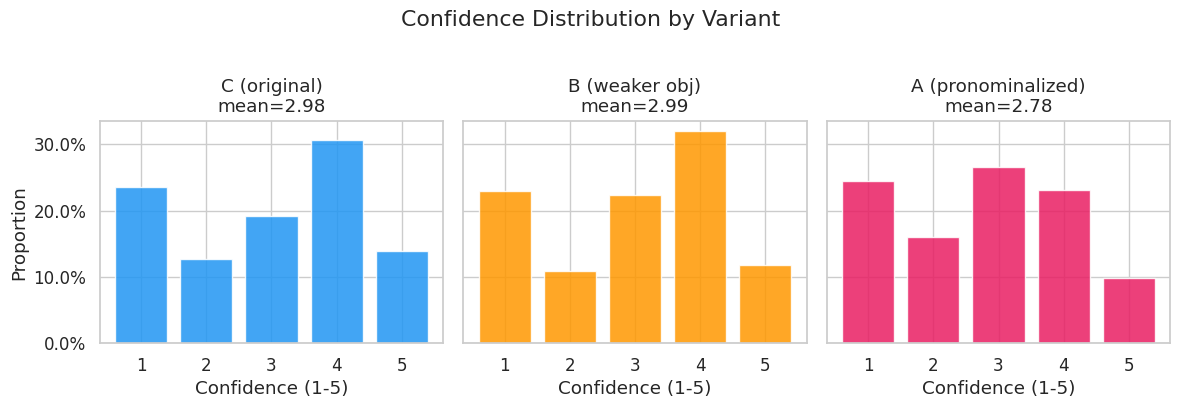

In [326]:
conf_var = df.groupby('variant')['confidence'].agg(['mean','sem'])
conf_var = conf_var.loc[VARIANT_ORDER]
print('Confidence (1-5) by variant:')
print(conf_var.round(3))

fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=True)
for ax, var in zip(axes, VARIANT_ORDER):
    sub = df[df['variant'] == var]['confidence']
    counts = sub.value_counts().sort_index()
    ax.bar(counts.index, counts.values / counts.sum(),
           color=VARIANT_COLORS[var], edgecolor='white', alpha=0.85)
    ax.set_title(f'{VARIANT_LABELS[var]}\nmean={sub.mean():.2f}')
    ax.set_xlabel('Confidence (1-5)')
    ax.set_xticks([1,2,3,4,5])
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
axes[0].set_ylabel('Proportion')
plt.suptitle('Confidence Distribution by Variant', y=1.02)
plt.tight_layout()
plt.show()

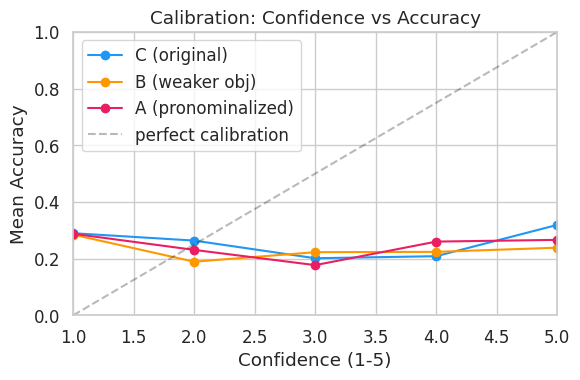

In [327]:
# Accuracy vs confidence (calibration check)
cal = df.groupby(['variant','confidence'])['accuracy'].mean().unstack(level=0)
fig, ax = plt.subplots(figsize=(6,4))
for var in VARIANT_ORDER:
    if var in cal.columns:
        ax.plot(cal.index, cal[var], marker='o', label=VARIANT_LABELS[var],
                color=VARIANT_COLORS[var])
ax.plot([1,5],[0,1], 'k--', alpha=0.3, label='perfect calibration')
ax.set_xlabel('Confidence (1-5)')
ax.set_ylabel('Mean Accuracy')
ax.set_title('Calibration: Confidence vs Accuracy')
ax.legend()
ax.set_xlim(1,5); ax.set_ylim(0,1)
plt.tight_layout()
plt.show()

## 3. Response Time

Response time (seconds) by variant:
         median  mean
variant              
A          4.36  6.21
B          4.22  6.26
C          3.97  6.24


/tmp/ipykernel_1919633/897593536.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_plot, labels=[VARIANT_LABELS[v] for v in VARIANT_ORDER],


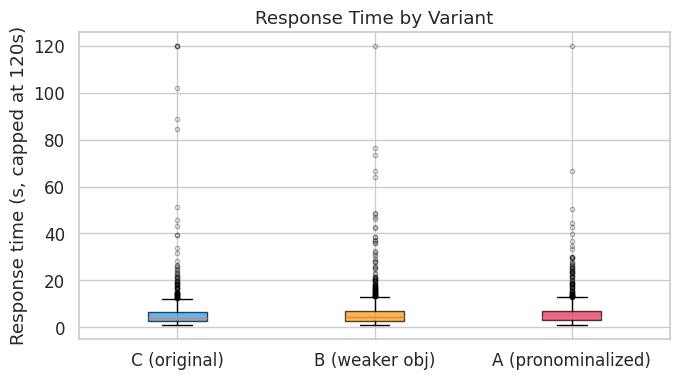

In [328]:
# Cap outliers at 120s for visualization
df['time_s_cap'] = df['time_s'].clip(upper=120)

time_var = df.groupby('variant')['time_s'].agg(['median','mean'])
print('Response time (seconds) by variant:')
print(time_var.round(2))

fig, ax = plt.subplots(figsize=(7, 4))
data_plot = [df[df['variant']==v]['time_s_cap'].values for v in VARIANT_ORDER]
bp = ax.boxplot(data_plot, labels=[VARIANT_LABELS[v] for v in VARIANT_ORDER],
                patch_artist=True, showfliers=True,
                flierprops=dict(marker='.', alpha=0.3))
for patch, var in zip(bp['boxes'], VARIANT_ORDER):
    patch.set_facecolor(VARIANT_COLORS[var])
    patch.set_alpha(0.7)
ax.set_ylabel('Response time (s, capped at 120s)')
ax.set_title('Response Time by Variant')
plt.tight_layout()
plt.show()

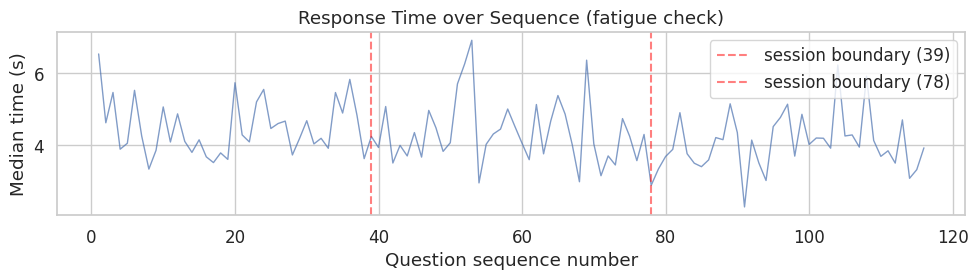

In [329]:
# Response time over sequence (fatigue check)
time_seq = df.groupby('seq')['time_s_cap'].median().reset_index()
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(time_seq['seq'], time_seq['time_s_cap'], alpha=0.7, linewidth=1)
# Mark session boundaries (117 questions per session)
for boundary in [39, 78]:
    ax.axvline(boundary, color='red', linestyle='--', alpha=0.5, label=f'session boundary ({boundary})')
ax.set_xlabel('Question sequence number')
ax.set_ylabel('Median time (s)')
ax.set_title('Response Time over Sequence (fatigue check)')
ax.legend()
plt.tight_layout()
plt.show()

In [330]:
# Response time by session
time_sess = df.groupby(['session','variant'])['time_s'].median().unstack()[VARIANT_ORDER]
print('Median response time (s) by session × variant:')
print(time_sess.round(2))

Median response time (s) by session × variant:
variant     C     B     A
session                  
1         NaN   NaN  4.36
2         NaN  4.22   NaN
3        3.97   NaN   NaN


## 4. Accuracy by Entity Type and Op

In [331]:
# ── Accuracy by entity group — all model groups (inst_blind) ─────────────────
from collections import defaultdict as _dd

_CT    = {'question': 'C', 'weaker_object': 'B', 'pronominalized': 'A'}
_q_ids = set(df['question_id'].tolist())

ALL_MODEL_GROUPS = {
    'VLM': {
        'dir': BASE / 'evaluation/logits/pretrained',
        'models': {
            'Qwen3-VL-8B': 'Qwen3-VL-8B-Instruct',
            'LLaVA-1.5-7B': 'llava-1.5-7b-hf',
            'LLaVA-Mistral': 'llava-v1.6-mistral-7b-hf',
            'LLaVA-Vicuna':  'llava-v1.6-vicuna-7b-hf',
        },
    },
    'LM-decoder': {
        'dir': BASE / 'evaluation/logits/lm_decoder/pretrained',
        'models': {
            'LLaVA-1.5 (LM)':   'llava-1.5-7b-hf',
            'LLaVA-Mistral (LM)':'llava-v1.6-mistral-7b-hf',
            'LLaVA-Vicuna (LM)': 'llava-v1.6-vicuna-7b-hf',
        },
    },
    'Backbone LLM': {
        'dir': BASE / 'evaluation/logits/backbone/pretrained',
        'models': {
            'Qwen3-8B': 'Qwen3-8B',
        },
    },
}
GROUP_COLORS = {'VLM': '#E91E63', 'LM-decoder': '#2196F3', 'Backbone LLM': '#FF9800'}

_ent_map = df[['question_id','ent']].drop_duplicates().set_index('question_id')['ent']

# Load per-model per-question accuracy, then compute group means per entity
group_ent_acc = {}   # gname → ent → variant → mean_acc
group_q_acc   = {}   # gname → per-question DataFrame (mean across group models)

for gname, ginfo in ALL_MODEL_GROUPS.items():
    model_dfs = []
    for label, mdir in ginfo['models'].items():
        path = ginfo['dir'] / mdir / 'vqa_1k_control_inst_blind.jsonl'
        if not path.exists(): continue
        _raw = _dd(lambda: _dd(list))
        for line in open(path):
            ex  = json.loads(line)
            qid = int(ex['question_id'])
            if qid not in _q_ids: continue
            gt  = mapper.get_answers(qid)
            ga  = ex.get('generated_answers', {})
            for ct, var in _CT.items():
                ans = _clean_answer(ga.get(ct, ''))
                if ans and gt:
                    _raw[qid][var].append(vqa_accuracy(ans, gt))
        rows_m = [{'question_id': qid,
                   **{var: float(np.mean(_raw[qid][var])) if _raw[qid][var] else np.nan
                      for var in VARIANT_ORDER}}
                  for qid in _q_ids]
        model_dfs.append(pd.DataFrame(rows_m).set_index('question_id'))

    if not model_dfs: continue
    # Mean across models in the group
    grp_mean = pd.concat(model_dfs).groupby(level=0).mean()
    group_q_acc[gname] = grp_mean

    # Per entity-group mean
    grp2 = grp_mean.join(_ent_map)
    group_ent_acc[gname] = grp2.groupby('ent')[VARIANT_ORDER].mean()

# Human accuracy per original entity type
acc_ent = df.groupby(['ent','variant'])['accuracy'].mean().unstack()[VARIANT_ORDER]
ENT_ORDER = sorted(acc_ent.index.tolist())
acc_ent = acc_ent.reindex(ENT_ORDER)

print('Groups loaded:', list(group_ent_acc.keys()))
print('\nHuman accuracy by entity type × variant:')
print(acc_ent.round(3))


Groups loaded: ['VLM', 'LM-decoder', 'Backbone LLM']

Human accuracy by entity type × variant:
variant      C      B      A
ent                         
animal   0.317  0.179  0.188
food     0.207  0.100  0.087
object   0.208  0.167  0.144
other    0.100  0.122  0.156
person   0.193  0.133  0.122
place    0.600  0.400  0.450
product  0.175  0.225  0.192
text     0.000  0.000  0.000
vehicle  0.233  0.333  0.033


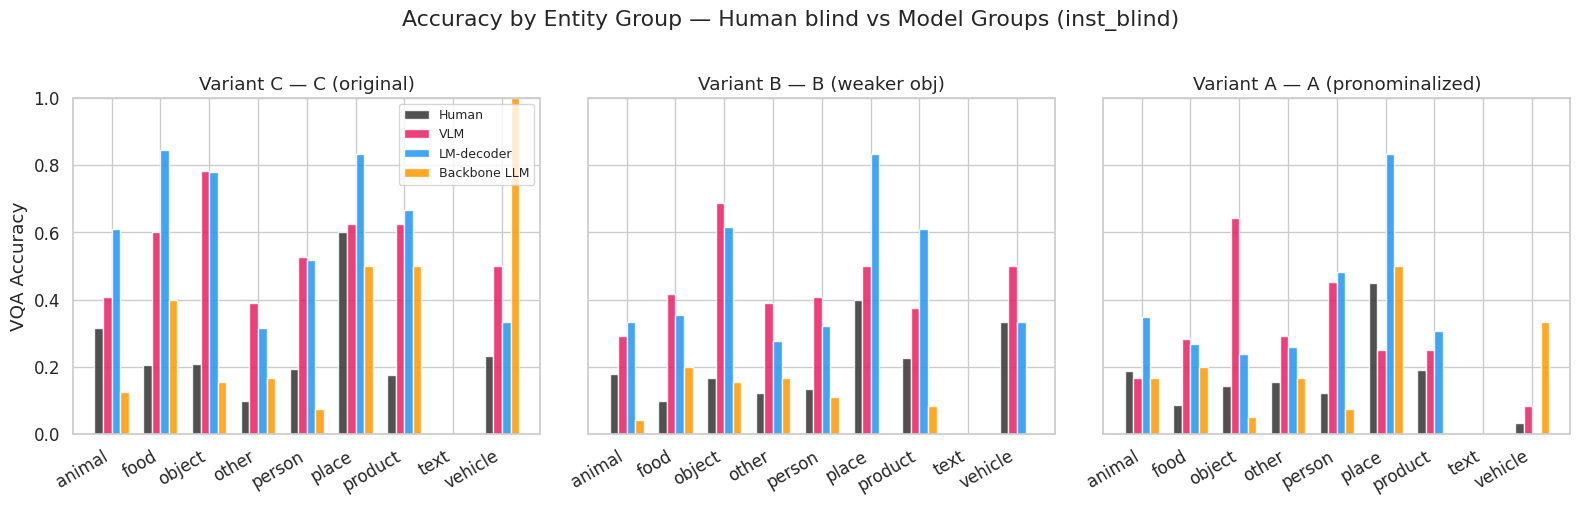

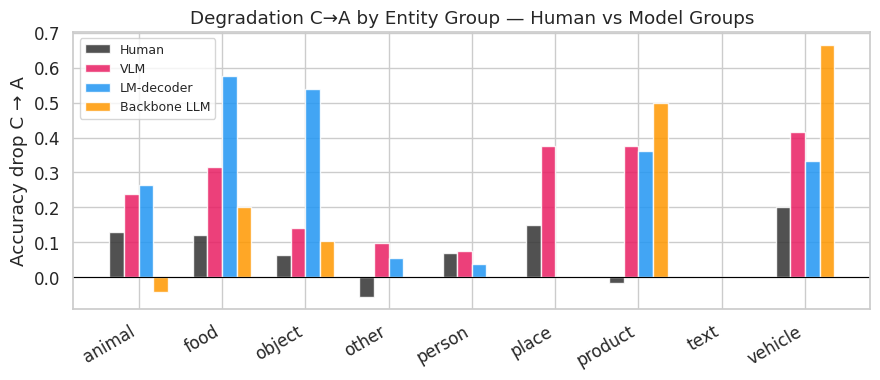

In [332]:
# ── Grouped bar: human + VLM / LM-decoder / Backbone per entity group ─────────
ent_order = ENT_ORDER
x         = np.arange(len(ent_order))
srcs      = [('Human', None, '#333333')] + [(g, None, GROUP_COLORS[g]) for g in ALL_MODEL_GROUPS]
n_src     = len(srcs)
w         = 0.7 / n_src
offsets   = np.linspace(-(n_src-1)/2, (n_src-1)/2, n_src) * w

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
for ax_i, var in enumerate(VARIANT_ORDER):
    ax = axes[ax_i]
    for (label, _, color), offset in zip(srcs, offsets):
        if label == 'Human':
            vals = [acc_ent.loc[e, var] if e in acc_ent.index else np.nan for e in ent_order]
        else:
            mea = group_ent_acc.get(label, pd.DataFrame())
            vals = [mea.loc[e, var] if e in mea.index else np.nan for e in ent_order]
        ax.bar(x + offset, vals, w, color=color, alpha=0.85, edgecolor='white',
               label=label if ax_i == 0 else '_nolegend_')
    ax.set_xticks(x); ax.set_xticklabels(ent_order, rotation=30, ha='right')
    ax.set_title(f'Variant {var} — {VARIANT_LABELS[var]}')
    ax.set_ylim(0, 1)
    if ax_i == 0:
        ax.set_ylabel('VQA Accuracy')

axes[0].legend(fontsize=9, loc='upper right')
plt.suptitle('Accuracy by Entity Group — Human blind vs Model Groups (inst_blind)', y=1.01)
plt.tight_layout()
plt.show()

# ── Degradation C→A: human + 3 model groups per entity ───────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
human_deg = (acc_ent['C'] - acc_ent['A']).reindex(ent_order)

all_degs = [('Human', human_deg, '#333333')] + [
    (gname, (group_ent_acc[gname]['C'] - group_ent_acc[gname]['A']).reindex(ent_order),
     GROUP_COLORS[gname])
    for gname in ALL_MODEL_GROUPS if gname in group_ent_acc
]
n    = len(all_degs)
w    = 0.7 / n
offs = np.linspace(-(n-1)/2, (n-1)/2, n) * w

for (label, deg_vals, color), off in zip(all_degs, offs):
    ax.bar(x + off, deg_vals, w, color=color, alpha=0.85,
           edgecolor='white', label=label)

ax.axhline(0, color='black', lw=0.8)
ax.set_xticks(x); ax.set_xticklabels(ent_order, rotation=30, ha='right')
ax.set_ylabel('Accuracy drop C → A')
ax.set_title('Degradation C→A by Entity Group — Human vs Model Groups')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


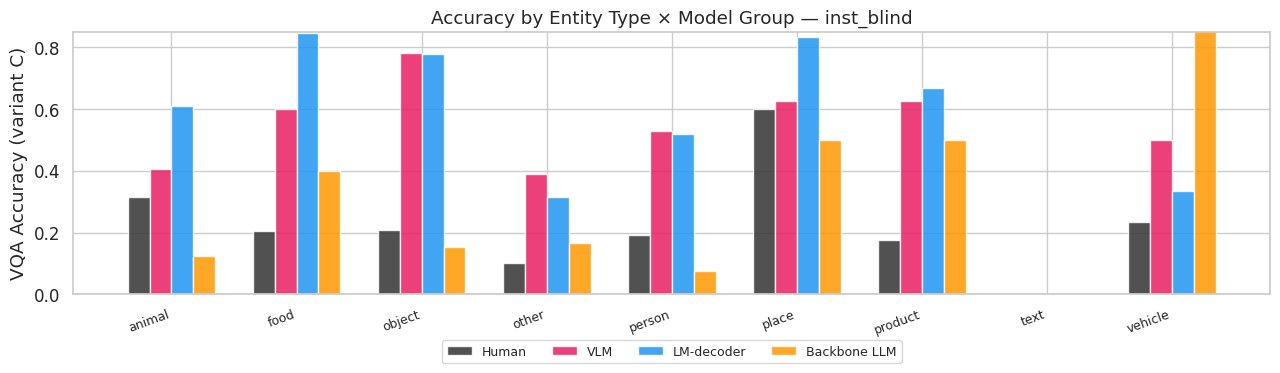

In [333]:
# ── Accuracy by entity type × model group (variant C, inst_blind) ────────────
# X-axis: entity types  |  bars: model groups (Human / VLM / LM-decoder / Backbone)
group_order  = ['Human'] + list(ALL_MODEL_GROUPS.keys())
GROUP_COLORS_EXT = {'Human': '#333333', **GROUP_COLORS}

x        = np.arange(len(ENT_ORDER))
n_groups = len(group_order)
w        = 0.7 / n_groups
offsets  = np.linspace(-(n_groups-1)/2, (n_groups-1)/2, n_groups) * w

fig, ax = plt.subplots(figsize=(13, 4))
for gname, offset in zip(group_order, offsets):
    if gname == 'Human':
        vals = [acc_ent.loc[e, 'C'] if e in acc_ent.index else np.nan for e in ENT_ORDER]
    else:
        mea  = group_ent_acc.get(gname, pd.DataFrame())
        vals = [mea.loc[e, 'C'] if e in mea.index else np.nan for e in ENT_ORDER]
    ax.bar(x + offset, vals, w, color=GROUP_COLORS_EXT[gname],
           alpha=0.85, edgecolor='white', label=gname)

ax.set_xticks(x)
ax.set_xticklabels(ENT_ORDER, fontsize=9, rotation=20, ha='right')
ax.set_ylabel('VQA Accuracy (variant C)')
ax.set_title('Accuracy by Entity Type × Model Group — inst_blind')
ax.set_ylim(0, 0.85)
ax.legend(fontsize=9, ncols=4, loc='upper center',bbox_to_anchor=(0.5, -0.15))
# ax.axhline(0.5, color='gray', ls='--', lw=0.7)
plt.tight_layout()
plt.show()


## 5. Question-Level Difficulty

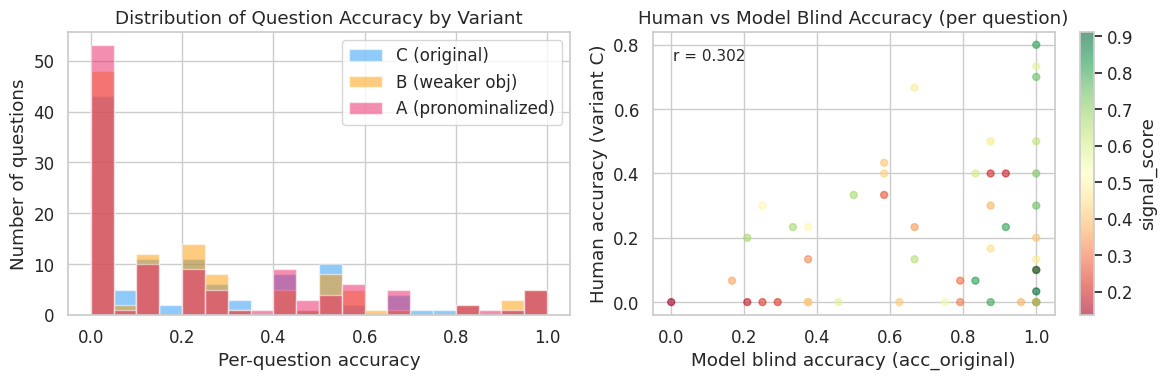

In [334]:
# Human difficulty h(q) per variant = 1 - accuracy
q_acc = df.groupby(['question_id','variant'])['accuracy'].mean().unstack()[VARIANT_ORDER]
q_acc['h_C'] = 1 - q_acc['C']
q_acc['degradation'] = q_acc['C'] - q_acc['A']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Distribution of per-question accuracy
ax = axes[0]
for var in VARIANT_ORDER:
    ax.hist(q_acc[var].dropna(), bins=20, alpha=0.5,
            label=VARIANT_LABELS[var], color=VARIANT_COLORS[var])
ax.set_xlabel('Per-question accuracy')
ax.set_ylabel('Number of questions')
ax.set_title('Distribution of Question Accuracy by Variant')
ax.legend()

# Human accuracy C vs blind model accuracy
ax = axes[1]
q_merged = q_acc.reset_index().merge(s2[['question_id','acc_original','signal_score']], on='question_id')
sc = ax.scatter(q_merged['acc_original'], q_merged['C'],
                c=q_merged['signal_score'], cmap='RdYlGn', alpha=0.6, s=25)
plt.colorbar(sc, ax=ax, label='signal_score')
ax.set_xlabel('Model blind accuracy (acc_original)')
ax.set_ylabel('Human accuracy (variant C)')
ax.set_title('Human vs Model Blind Accuracy (per question)')
r = q_merged[['acc_original','C']].dropna().corr().iloc[0,1]
ax.text(0.05, 0.9, f'r = {r:.3f}', transform=ax.transAxes, fontsize=11)

plt.tight_layout()
plt.show()

In [335]:
# Enrich with question text
q_lookup = {e['question_id']: e['question_en']
            for e in json.load(open(BASE/'experiment/s2_v2/s2_question.json'))}

q_acc_full = q_acc.reset_index().copy()
q_acc_full['question_en'] = q_acc_full['question_id'].map(q_lookup)

print('10 hardest (C):')
for _, row in q_acc_full.nsmallest(10,'C').iterrows():
    print(f"  {row['question_id']} acc={row['C']:.2f} deg={row['degradation']:.2f}  {row['question_en']}")

print('\n10 easiest (C):')
for _, row in q_acc_full.nlargest(10,'C').iterrows():
    print(f"  {row['question_id']} acc={row['C']:.2f} deg={row['degradation']:.2f}  {row['question_en']}")

10 hardest (C):
  1342072 acc=0.00 deg=0.00  What kind of information does the yellow and white book look like it contains?
  32001021 acc=0.00 deg=-0.70  Is there a couch?
  73521003 acc=0.00 deg=0.00  What location is the luggage at?
  83277003 acc=0.00 deg=0.00  What is the man doing?
  91236000 acc=0.00 deg=0.00  What formation are the aircraft in?
  121442004 acc=0.00 deg=0.00  How many kids have glasses?
  121839003 acc=0.00 deg=0.00  What are the ladies wearing on their head's?
  169996009 acc=0.00 deg=0.00  What is the name of the store closest to the van?
  187196001 acc=0.00 deg=0.00  What does the shirt say?
  205625000 acc=0.00 deg=0.00  What does the mile say?

10 easiest (C):
  199876000 acc=1.00 deg=0.00  Are these women friends?
  219492002 acc=1.00 deg=0.00  Are cats really afraid to get into water?
  335047002 acc=1.00 deg=0.00  Is there a hot dog in there?
  374111001 acc=1.00 deg=0.00  Are the chips fresh?
  502630003 acc=1.00 deg=0.00  Is the animal in the foregrou

## 6. Human vs Model Alignment

In [336]:
# Load model inst_blind accuracies — all three model types
import re as _re
from collections import defaultdict
from utils.vqa import VQAAnswerMapper, vqa_accuracy

def _clean_answer(ans):
    """Strip <think>...</think> CoT prefix (Qwen3 backbone), then take first sentence."""
    ans = _re.sub(r'<think>.*?</think>\s*', '', ans, flags=_re.DOTALL).strip()
    return ans

ALL_MODELS = {
    # label → (results_dir, folder_name)
    # VLM
    'Qwen3-VL-8B':   (BASE / 'evaluation/logits/pretrained',              'Qwen3-VL-8B-Instruct'),
    'LLaVA-1.5-7B':  (BASE / 'evaluation/logits/pretrained',              'llava-1.5-7b-hf'),
    'LLaVA-Mistral': (BASE / 'evaluation/logits/pretrained',              'llava-v1.6-mistral-7b-hf'),
    'LLaVA-Vicuna':  (BASE / 'evaluation/logits/pretrained',              'llava-v1.6-vicuna-7b-hf'),
    # LM-decoder
    'LLaVA-1.5 (LM)':    (BASE / 'evaluation/logits/lm_decoder/pretrained', 'llava-1.5-7b-hf'),
    'LLaVA-Mistral (LM)':(BASE / 'evaluation/logits/lm_decoder/pretrained', 'llava-v1.6-mistral-7b-hf'),
    'LLaVA-Vicuna (LM)': (BASE / 'evaluation/logits/lm_decoder/pretrained', 'llava-v1.6-vicuna-7b-hf'),
    # Backbone LLM
    # Vicuna-7B excluded — all answers empty (generation failure)
    # Mistral-7B excluded — refuses to answer without image (0% accuracy)
    'Qwen3-8B':   (BASE / 'evaluation/logits/backbone/pretrained', 'Qwen3-8B'),
}
CT_TO_VARIANT = {'question': 'C', 'weaker_object': 'B', 'pronominalized': 'A'}

q_ids = set(df['question_id'].tolist())
model_acc_raw = defaultdict(lambda: defaultdict(lambda: defaultdict(list)))

for label, (results_dir, mdir) in ALL_MODELS.items():
    path = results_dir / mdir / 'vqa_1k_control_inst_blind.jsonl'
    if not path.exists():
        print(f'  MISSING: {label} — {path}')
        continue
    for line in open(path):
        ex  = json.loads(line)
        qid = int(ex['question_id'])
        if qid not in q_ids: continue
        gt  = mapper.get_answers(qid)
        ga  = ex.get('generated_answers', {})
        for ct, var in CT_TO_VARIANT.items():
            ans = _clean_answer(ga.get(ct, ''))
            if ans and gt:
                model_acc_raw[label][qid][var].append(vqa_accuracy(ans, gt))

model_q_acc = {}
for label in ALL_MODELS:
    if label not in model_acc_raw: continue
    rows_m = []
    for qid in q_ids:
        row = {'question_id': qid}
        for var in VARIANT_ORDER:
            vals = model_acc_raw[label][qid][var]
            row[var] = float(np.mean(vals)) if vals else np.nan
        rows_m.append(row)
    model_q_acc[label] = pd.DataFrame(rows_m).set_index('question_id')

# Tag each model with its group for downstream use
MODEL_TYPE = {
    'Qwen3-VL-8B': 'VLM', 'LLaVA-1.5-7B': 'VLM', 'LLaVA-Mistral': 'VLM', 'LLaVA-Vicuna': 'VLM',
    'LLaVA-1.5 (LM)': 'LM-decoder', 'LLaVA-Mistral (LM)': 'LM-decoder', 'LLaVA-Vicuna (LM)': 'LM-decoder',
    'Qwen3-8B': 'Backbone LLM',
}

print('Loaded inst_blind for:', list(model_q_acc.keys()))
for label, mdf in model_q_acc.items():
    n = mdf['C'].notna().sum()
    print(f'  [{MODEL_TYPE[label]:12}] {label}: {n} questions, mean C = {mdf["C"].mean():.3f}')


Loaded inst_blind for: ['Qwen3-VL-8B', 'LLaVA-1.5-7B', 'LLaVA-Mistral', 'LLaVA-Vicuna', 'LLaVA-1.5 (LM)', 'LLaVA-Mistral (LM)', 'LLaVA-Vicuna (LM)', 'Qwen3-8B']
  [VLM         ] Qwen3-VL-8B: 116 questions, mean C = 0.474
  [VLM         ] LLaVA-1.5-7B: 116 questions, mean C = 0.468
  [VLM         ] LLaVA-Mistral: 116 questions, mean C = 0.532
  [VLM         ] LLaVA-Vicuna: 116 questions, mean C = 0.511
  [LM-decoder  ] LLaVA-1.5 (LM): 116 questions, mean C = 0.532
  [LM-decoder  ] LLaVA-Mistral (LM): 116 questions, mean C = 0.526
  [LM-decoder  ] LLaVA-Vicuna (LM): 116 questions, mean C = 0.437
  [Backbone LLM] Qwen3-8B: 116 questions, mean C = 0.158


In [337]:
# Spearman / Pearson / Kendall τ — human blind vs model inst_blind per question
from scipy.stats import pearsonr, spearmanr, kendalltau

results = []
for var in VARIANT_ORDER:
    h_var = q_acc[var].dropna().rename('human')
    for label, mdf in model_q_acc.items():
        merged = h_var.reset_index().merge(
            mdf[var].dropna().reset_index(), on='question_id'
        ).dropna()
        if len(merged) < 5: continue
        r,   _ = pearsonr( merged['human'], merged[var])
        rho, _ = spearmanr(merged['human'], merged[var])
        tau, _ = kendalltau(merged['human'], merged[var])
        results.append({'model': label, 'type': MODEL_TYPE.get(label, '?'), 'variant': var,
                        'pearson_r': r, 'spearman_rho': rho,
                        'kendall_tau': tau, 'n': len(merged)})

rdf = pd.DataFrame(results)

# Print grouped by model type
print('Correlation: human blind accuracy vs model inst_blind accuracy per question')
print('(Pearson r | Spearman ρ | Kendall τ)')
print(f'{"model":22}  {"type":12}  {"C":>22}  {"B":>22}  {"A":>22}')
print('-' * 105)
for mtype in ['VLM', 'LM-decoder', 'Backbone LLM']:
    for label in model_q_acc:
        if MODEL_TYPE.get(label) != mtype: continue
        parts = []
        for var in VARIANT_ORDER:
            sub = rdf[(rdf.model == label) & (rdf.variant == var)]
            if sub.empty:
                parts.append(f'{"n/a":>22}')
            else:
                r = sub.iloc[0]
                parts.append(f'{r.pearson_r:+.3f} {r.spearman_rho:+.3f} {r.kendall_tau:+.3f}')
        print(f'{label:22}  {mtype:12}  {"  ".join(parts)}')
    print()


Correlation: human blind accuracy vs model inst_blind accuracy per question
(Pearson r | Spearman ρ | Kendall τ)
model                   type                               C                       B                       A
---------------------------------------------------------------------------------------------------------
Qwen3-VL-8B             VLM           +0.532 +0.570 +0.471  +0.553 +0.550 +0.470  +0.505 +0.470 +0.400
LLaVA-1.5-7B            VLM           +0.432 +0.462 +0.394  +0.457 +0.456 +0.387  +0.593 +0.553 +0.476
LLaVA-Mistral           VLM           +0.394 +0.445 +0.372  +0.548 +0.520 +0.441  +0.543 +0.513 +0.435
LLaVA-Vicuna            VLM           +0.398 +0.405 +0.341  +0.463 +0.431 +0.366  +0.583 +0.561 +0.479

LLaVA-1.5 (LM)          LM-decoder    +0.492 +0.526 +0.430  +0.514 +0.476 +0.396  +0.525 +0.465 +0.405
LLaVA-Mistral (LM)      LM-decoder    +0.470 +0.509 +0.422  +0.501 +0.461 +0.385  +0.512 +0.485 +0.413
LLaVA-Vicuna (LM)       LM-decoder    +0.456 +0.450 +

In [338]:
# Summary: mean accuracy + degradation C→A (inst_blind models vs human blind)
print(f'{"":25}  {"type":12}  {"C":>6} {"A":>6} {"C→A deg":>8}')
print('-' * 62)
for mtype in ['VLM', 'LM-decoder', 'Backbone LLM']:
    for label, mdf in model_q_acc.items():
        if MODEL_TYPE.get(label) != mtype: continue
        c = mdf['C'].mean(); a = mdf['A'].mean()
        print(f'{label:25}  {mtype:12}  {c:.3f}  {a:.3f}  {c-a:+.3f}')
    print()
h_c = df[df.variant=="C"]["accuracy"].mean()
h_a = df[df.variant=="A"]["accuracy"].mean()
n_p = df['participant_code'].nunique()
print(f'{f"Human (blind, N={n_p})":25}  {"—":12}  {h_c:.3f}  {h_a:.3f}  {h_c-h_a:+.3f}')

                           type               C      A  C→A deg
--------------------------------------------------------------
Qwen3-VL-8B                VLM           0.474  0.325  +0.149
LLaVA-1.5-7B               VLM           0.468  0.353  +0.115
LLaVA-Mistral              VLM           0.532  0.405  +0.126
LLaVA-Vicuna               VLM           0.511  0.417  +0.095

LLaVA-1.5 (LM)             LM-decoder    0.532  0.313  +0.218
LLaVA-Mistral (LM)         LM-decoder    0.526  0.362  +0.164
LLaVA-Vicuna (LM)          LM-decoder    0.437  0.296  +0.141

Qwen3-8B                   Backbone LLM  0.158  0.069  +0.089



KeyError: 'participant_code'

In [ ]:
# ── Degradation ladder: full 1k (dotted) vs s2_v2 sample (solid) ─────────────
# inst_blind condition for all model types + human (3 points: C/B/A only)
# Markers: ● VLM  ■ LM-decoder  ▲ Backbone LLM  ★ Human
from collections import defaultdict as _dd

CONTROL_TYPES  = ['question','deictic_removed','object_removed','weaker_object','pronominalized']
CT_LABELS      = ['Original\n(C)','Deictic\nremoved','Object\nremoved','Weaker\nobj (B)','Pronominalized\n(A)']
# Indices where human data maps to
HUMAN_CT_IDX   = {'C': 0, 'B': 3, 'A': 4}  # question, weaker_object, pronominalized

LOGIT_BASE = BASE / 'evaluation/logits'
MODEL_GROUPS = {
    'vlm': {
        'dir': LOGIT_BASE / 'pretrained',
        'marker': 'o', 'models': {
            'Qwen3-VL-8B':    'Qwen3-VL-8B-Instruct',
            'LLaVA-1.5-7B':   'llava-1.5-7b-hf',
            'LLaVA-Mistral':  'llava-v1.6-mistral-7b-hf',
            'LLaVA-Vicuna':   'llava-v1.6-vicuna-7b-hf',
        }
    },
    'lm_decoder': {
        'dir': LOGIT_BASE / 'lm_decoder/pretrained',
        'marker': 's', 'models': {
            'LLaVA-1.5 (LM)':  'llava-1.5-7b-hf',
            'LLaVA-Mistral (LM)': 'llava-v1.6-mistral-7b-hf',
            'LLaVA-Vicuna (LM)':  'llava-v1.6-vicuna-7b-hf',
        }
    },
    'backbone': {
        'dir': LOGIT_BASE / 'backbone/pretrained',
        'marker': '^', 'models': {
            'Qwen3-8B': 'Qwen3-8B',
        }
    },
}

def load_ct_acc(model_dir, qid_filter=None):
    path = model_dir / 'vqa_1k_control_inst_blind.jsonl'
    if not path.exists():
        return {}
    ct_acc = _dd(list)
    for line in open(path):
        ex  = json.loads(line)
        qid = int(ex['question_id'])
        if qid_filter and qid not in qid_filter:
            continue
        gt = mapper.get_answers(qid)
        ga = ex.get('generated_answers', {})
        for ct in CONTROL_TYPES:
            ans = _clean_answer(ga.get(ct, ''))
            if ans and gt:
                ct_acc[ct].append(vqa_accuracy(ans, gt))
    return {ct: float(np.mean(v)) for ct, v in ct_acc.items() if v}

sample_qids = set(df['question_id'].tolist())
x = np.arange(len(CONTROL_TYPES))

# Collect data
curves = []  # list of (label, gname, marker, means_sample, means_full)
for gname, ginfo in MODEL_GROUPS.items():
    for label, mdir in ginfo['models'].items():
        mpath = ginfo['dir'] / mdir
        s_acc = load_ct_acc(mpath, qid_filter=sample_qids)
        f_acc = load_ct_acc(mpath, qid_filter=None)
        if not s_acc and not f_acc:
            continue
        s_vals = [s_acc.get(ct, np.nan) for ct in CONTROL_TYPES]
        f_vals = [f_acc.get(ct, np.nan) for ct in CONTROL_TYPES]
        curves.append((label, gname, ginfo['marker'], s_vals, f_vals))

# Human 3-point curve
h_vals = [np.nan] * len(CONTROL_TYPES)
for var, idx in HUMAN_CT_IDX.items():
    h_vals[idx] = df[df.variant == var]['accuracy'].mean()

# ── Plot ──────────────────────────────────────────────────────────────────────
cmap = plt.get_cmap('tab10')
label_colors = {c[0]: cmap(i % 10) for i, c in enumerate(curves)}

fig, ax = plt.subplots(figsize=(11, 5))

for label, gname, marker, s_vals, f_vals in curves:
    color = label_colors[label]
    # Sample: solid line
    ax.plot(x, s_vals, color=color, marker=marker, ls='-',
            linewidth=1.8, markersize=6, alpha=0.9,
            label=f'{label}')
    # Full 1k: dotted line, no legend entry
    if any(not np.isnan(v) for v in f_vals):
        ax.plot(x, f_vals, color=color, marker=marker, ls=':',
                linewidth=1.2, markersize=4, alpha=0.5,
                label='_nolegend_')

# Human: stars at 3 points
h_x = [i for i, v in enumerate(h_vals) if not np.isnan(v)]
h_y = [v for v in h_vals if not np.isnan(v)]
ax.plot(h_x, h_y, color='black', marker='*', ls='--',
        linewidth=1.5, markersize=12, zorder=5, label='Human blind (N=9)')

ax.set_xticks(x)
ax.set_xticklabels(CT_LABELS, fontsize=9)
ax.set_ylabel('VQA Accuracy (inst_blind)')
ax.set_ylim(0, 0.6)
ax.set_title(
    'Degradation Ladder — inst_blind\n'
    'Solid = s2_v2 sample (116q) · Dotted = full 1k · ●VLM ■LM-dec ▲LLM ★Human'
)

# Compact legend: two columns
ax.legend(fontsize=7.5, ncol=3, loc='upper right', framealpha=0.85)
plt.tight_layout()
plt.show()


## 7. Calibration — Human Confidence vs Model Logprob Confidence

/home/david/miniconda3/envs/aide/lib/python3.11/site-packages/scipy/stats/_stats_py.py:4781: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))


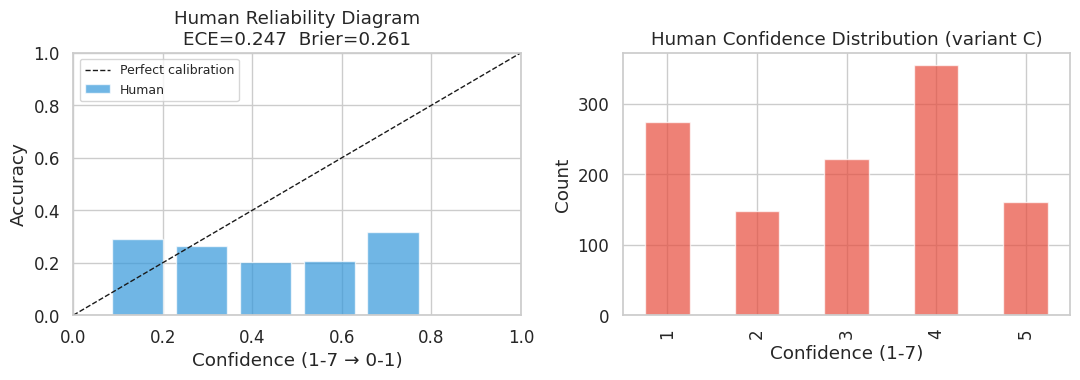

ECE:         0.2470
Brier score: 0.2608
Conf-accuracy Pearson r per participant (mean): 0.028
  8HLCRUY1: r=0.014
  DPCN9S37: r=0.230
  FLWP3ZF7: r=-0.058
  HB857QDA: r=0.216
  J09HHJXK: r=0.080
  K8VD3TYB: r=-0.195
  MPOMQQNU: r=0.002
  NVF556XP: r=0.130
  ZEF2XJBX: r=-0.169


In [339]:
# ── Human calibration ────────────────────────────────────────────────────────
# Human confidence is on a 1-7 scale; treat conf/7 as probability estimate
# Metrics:
#   Reliability diagram: binned confidence vs mean accuracy
#   ECE (Expected Calibration Error): weighted mean |acc - conf| per bin
#   Brier score: mean((conf/7 - correct)²)

from scipy.stats import pearsonr

cal_df = df[df.variant == 'C'].copy()
cal_df['conf_prob'] = cal_df['confidence'] / 7.0
cal_df['correct']   = cal_df['accuracy'].round().astype(float)  # 0 or 1 for Brier

N_BINS = 7
bins = np.linspace(0, 1, N_BINS + 1)
cal_df['conf_bin'] = pd.cut(cal_df['conf_prob'], bins=bins, labels=False, include_lowest=True)

bin_stats = cal_df.groupby('conf_bin').agg(
    mean_conf=('conf_prob', 'mean'),
    mean_acc=('accuracy', 'mean'),
    n=('accuracy', 'count')
).dropna()

ece   = (bin_stats['n'] / len(cal_df) * (bin_stats['mean_acc'] - bin_stats['mean_conf']).abs()).sum()
brier = ((cal_df['conf_prob'] - cal_df['correct']) ** 2).mean()

# Confidence-accuracy correlation per participant
conf_acc_corr = cal_df.groupby('participant').apply(
    lambda g: pearsonr(g['conf_prob'], g['accuracy'])[0] if len(g) > 5 else np.nan
).dropna()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Reliability diagram
ax = axes[0]
ax.bar(bin_stats['mean_conf'], bin_stats['mean_acc'],
       width=1/N_BINS * 0.8, alpha=0.7, color='#3498db', label='Human')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Perfect calibration')
ax.set_xlabel('Confidence (1-7 → 0-1)'); ax.set_ylabel('Accuracy')
ax.set_title(f'Human Reliability Diagram\nECE={ece:.3f}  Brier={brier:.3f}')
ax.legend(fontsize=9); ax.set_xlim(0, 1); ax.set_ylim(0, 1)

# Confidence distribution
ax = axes[1]
cal_df['confidence'].value_counts().sort_index().plot(kind='bar', ax=ax, color='#e74c3c', alpha=0.7)
ax.set_xlabel('Confidence (1-7)'); ax.set_ylabel('Count')
ax.set_title(f'Human Confidence Distribution (variant C)')

plt.tight_layout(); plt.show()

print(f'ECE:         {ece:.4f}')
print(f'Brier score: {brier:.4f}')
print(f'Conf-accuracy Pearson r per participant (mean): {conf_acc_corr.mean():.3f}')
for pid, r in conf_acc_corr.items():
    print(f'  {pid}: r={r:.3f}')


Qwen3-VL-8B: 27 yes/no questions with logprobs
LLaVA-1.5-7B: 29 yes/no questions with logprobs
LLaVA-Mistral: 29 yes/no questions with logprobs
LLaVA-Vicuna: 29 yes/no questions with logprobs


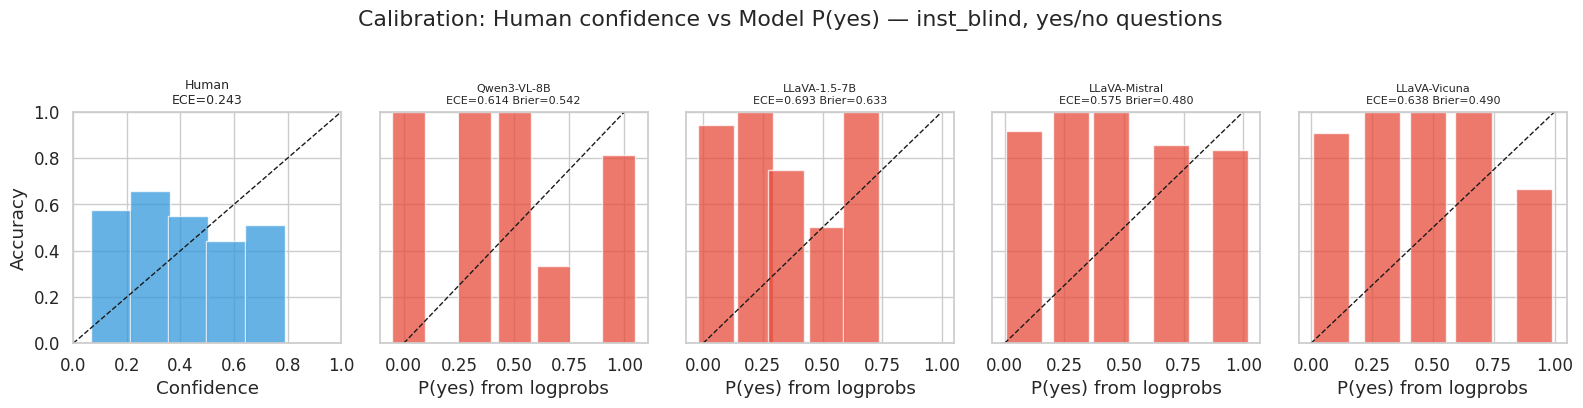

In [340]:
# ── Model calibration from logprobs (inst_blind, yes/no questions only) ──────
# For yes/no questions: extract P(yes) from top-5 logprobs of first token
# Use softmax over {yes, no} tokens to get calibrated probability
# ECE and reliability diagram compared to human calibration

import math

def extract_yn_prob(logits_content):
    """Extract P(yes) from top-5 first-token logits. Returns None if yes/no not in top-5."""
    if not logits_content: return None
    top = logits_content[0]['top_logprobs']
    yn_lp = {}
    for t in top:
        tok = t['token'].strip().lower()
        if tok in ('yes', 'no') and tok not in yn_lp:
            yn_lp[tok] = t['logprob']
    if 'yes' not in yn_lp and 'no' not in yn_lp:
        return None
    # softmax over yes/no only
    lp_yes = yn_lp.get('yes', -30.0)
    lp_no  = yn_lp.get('no',  -30.0)
    p_yes = math.exp(lp_yes) / (math.exp(lp_yes) + math.exp(lp_no))
    return p_yes

# Load inst_blind logprobs for yes/no questions
yn_qids = set(df[df.variant == 'C']['question_id'].tolist())
# filter to questions where GT is yes/no
yn_gt_qids = {qid for qid in yn_qids
              if any(a in ('yes','no') for a in (mapper.get_answers(qid) or []))}

model_calib = {}  # label → list of (p_yes, correct)
for label, mdir in MODELS.items():
    path = RESULTS_DIR / mdir / 'vqa_1k_control_inst_blind.jsonl'
    if not path.exists(): continue
    records = []
    for line in open(path):
        ex = json.loads(line)
        qid = int(ex['question_id'])
        if qid not in yn_gt_qids: continue
        gl = ex.get('generated_logits', {}).get('question', {}).get('content')
        p_yes = extract_yn_prob(gl)
        if p_yes is None: continue
        gt  = mapper.get_answers(qid)
        ans = ex.get('generated_answers', {}).get('question', '').strip().lower()
        correct = float(vqa_accuracy(ans, gt)) if gt else np.nan
        if not np.isnan(correct):
            records.append({'p_yes': p_yes, 'correct': correct,
                            'predicted_yes': int(p_yes >= 0.5)})
    model_calib[label] = records
    print(f'{label}: {len(records)} yes/no questions with logprobs')

# Reliability diagrams: human vs models
N_BINS = 5
fig, axes = plt.subplots(1, len(MODELS) + 1, figsize=(16, 4), sharey=True)

# Human (yes/no only)
cal_yn = df[(df.variant == 'C') & df['question_id'].isin(yn_gt_qids)].copy()
cal_yn['conf_prob'] = cal_yn['confidence'] / 7.0
h_bins = pd.cut(cal_yn['conf_prob'], bins=N_BINS).cat.categories
h_bin_stats = cal_yn.groupby(pd.cut(cal_yn['conf_prob'], bins=N_BINS)).agg(
    mean_conf=('conf_prob', 'mean'), mean_acc=('accuracy', 'mean'), n=('accuracy', 'count')
).dropna()
h_ece = (h_bin_stats['n'] / len(cal_yn) * (h_bin_stats['mean_acc'] - h_bin_stats['mean_conf']).abs()).sum()

ax = axes[0]
ax.bar(h_bin_stats['mean_conf'], h_bin_stats['mean_acc'],
       width=0.15, alpha=0.75, color='#3498db')
ax.plot([0,1],[0,1],'k--',lw=1)
ax.set_title(f'Human\nECE={h_ece:.3f}', fontsize=9)
ax.set_ylabel('Accuracy'); ax.set_xlabel('Confidence')
ax.set_xlim(0,1); ax.set_ylim(0,1)

for ax, (label, records) in zip(axes[1:], model_calib.items()):
    rdf_m = pd.DataFrame(records)
    m_bins_cut = pd.cut(rdf_m['p_yes'], bins=N_BINS)
    m_bin_stats = rdf_m.groupby(m_bins_cut).agg(
        mean_conf=('p_yes', 'mean'), mean_acc=('correct', 'mean'), n=('correct', 'count')
    ).dropna()
    m_ece = (m_bin_stats['n'] / len(rdf_m) * (m_bin_stats['mean_acc'] - m_bin_stats['mean_conf']).abs()).sum()
    m_brier = ((rdf_m['p_yes'] - rdf_m['correct']) ** 2).mean()
    ax.bar(m_bin_stats['mean_conf'], m_bin_stats['mean_acc'],
           width=0.15, alpha=0.75, color='#e74c3c')
    ax.plot([0,1],[0,1],'k--',lw=1)
    ax.set_title(f'{label}\nECE={m_ece:.3f} Brier={m_brier:.3f}', fontsize=8)
    ax.set_xlabel('P(yes) from logprobs')

plt.suptitle('Calibration: Human confidence vs Model P(yes) — inst_blind, yes/no questions', y=1.02)
plt.tight_layout(); plt.show()


Answer agreement rate: human vs model (inst_blind, yes/no, variant C)
        model  agreement  human_yes_rate  model_yes_rate   n
  Qwen3-VL-8B      0.478           0.687           0.366 268
 LLaVA-1.5-7B      0.343           0.687           0.142 268
LLaVA-Mistral      0.442           0.688           0.294 269
 LLaVA-Vicuna      0.418           0.687           0.254 268


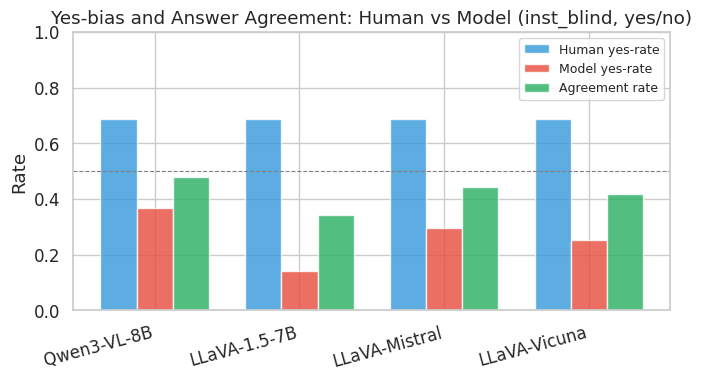

In [341]:
# ── Answer agreement rate: human vs model (yes/no questions, inst_blind) ─────
# Do human and model give the same answer regardless of GT?
# Measures alignment of priors independent of correctness

agree_rows = []
yn_df = df[(df.variant == 'C') & df['question_id'].isin(yn_gt_qids)].copy()
yn_df['answer_yn'] = yn_df['answer_en'].str.lower().str.strip().map(
    lambda x: x if x in ('yes','no') else None)
yn_df = yn_df.dropna(subset=['answer_yn'])

for label, records in model_calib.items():
    rec_map = {}  # qid → predicted_yes (1=yes, 0=no)
    path = RESULTS_DIR / MODELS[label] / 'vqa_1k_control_inst_blind.jsonl'
    if path.exists():
        for line in open(path):
            ex = json.loads(line)
            qid = int(ex['question_id'])
            if qid not in yn_gt_qids: continue
            ans = ex.get('generated_answers',{}).get('question','').strip().lower()
            if ans in ('yes','no'):
                rec_map[qid] = ans

    merged = yn_df.merge(
        pd.Series(rec_map, name='model_ans').reset_index().rename(columns={'index':'question_id'}),
        on='question_id', how='inner'
    )
    agree = (merged['answer_yn'] == merged['model_ans']).mean()
    h_yes  = (merged['answer_yn'] == 'yes').mean()
    m_yes  = (merged['model_ans'] == 'yes').mean()
    agree_rows.append({'model': label, 'agreement': agree,
                       'human_yes_rate': h_yes, 'model_yes_rate': m_yes,
                       'n': len(merged)})

agree_df = pd.DataFrame(agree_rows)
print('Answer agreement rate: human vs model (inst_blind, yes/no, variant C)')
print(agree_df.to_string(index=False, float_format='{:.3f}'.format))

# Yes-bias comparison bar chart
fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(len(agree_df))
w = 0.25
ax.bar(x - w, agree_df['human_yes_rate'],  w, label='Human yes-rate',  color='#3498db', alpha=0.8)
ax.bar(x,     agree_df['model_yes_rate'],  w, label='Model yes-rate',  color='#e74c3c', alpha=0.8)
ax.bar(x + w, agree_df['agreement'],       w, label='Agreement rate',  color='#27ae60', alpha=0.8)
ax.set_xticks(x); ax.set_xticklabels(agree_df['model'], rotation=15, ha='right')
ax.set_ylabel('Rate'); ax.set_ylim(0, 1)
ax.set_title('Yes-bias and Answer Agreement: Human vs Model (inst_blind, yes/no)')
ax.axhline(0.5, color='gray', ls='--', lw=0.8)
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()


## 8. Answer Agreement

In [ ]:
# Most common answers per question per variant
from collections import Counter

# For yes/no questions — bias check
q_info = pd.read_csv(BASE/'experiment/s2_v2/s2.csv')[['question_id','question_text']]
q_type = {e['question_id']: e['answer_type']
          for e in json.load(open(BASE/'experiment/s2_v2/s2_question.json'))}
df['answer_type'] = df['question_id'].map(q_type)

yesno_df = df[df['answer_type']=='yesno'].copy()
# Normalize yes/no answers in Korean
def normalize_yn(text):
    t = text.strip().lower()
    yes_kw = ['네','예','yes','맞','그렇','있어','있']
    no_kw = ['아니','no','없어','없']
    for kw in yes_kw:
        if kw in t: return 'yes'
    for kw in no_kw:
        if kw in t: return 'no'
    return 'other'

yesno_df['yn_norm'] = yesno_df['answer_kr'].apply(normalize_yn)
yn_bias = yesno_df.groupby(['variant','yn_norm']).size().unstack(fill_value=0)
yn_bias_pct = yn_bias.div(yn_bias.sum(axis=1), axis=0)
print('Yes/No answer distribution by variant:')
print(yn_bias_pct.round(3))

,question_id,ent,op,ent_grp,op_grp,cell,acc_original,acc_pronominalized,acc_range,acc_std,n_unique,signal_score,inst_acc_orig,inst_acc_range
0,33994009,object,spat,object,other_op,object|other_op,0.583333,0.500000,0.083333,0.076376,5,0.422436,0.416667,0.416667
1,567562000,object,count,object,other_op,object|other_op,0.250000,0.666667,-0.416667,0.177951,4,0.505128,0.666667,0.041667
2,205513003,object,attr,object,attr,object|attr,0.666667,0.000000,0.666667,0.289396,6,0.471795,0.333333,0.291667
3,326913000,animal,attr,animal,attr,animal|attr,1.000000,1.000000,0.000000,0.000000,1,0.290385,0.250000,0.250000
4,195862018,person,ident,person,other_op,person|other_op,0.875000,0.250000,0.625000,0.250000,3,0.522436,0.416667,-0.083333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,135076000,animal,attr,animal,attr,animal|attr,1.000000,0.875000,0.125000,0.100000,3,0.255128,0.166667,0.166667
96,72582004,person,act,person,other_op,person|other_op,0.416667,0.333333,0.083333,0.033333,2,0.334936,0.291667,0.125000
97,479149005,other,attr,misc,attr,misc|attr,0.625000,0.000000,0.625000,0.250000,7,0.493269,0.375000,0.375000
98,311950001,food,ident,scene,other_op,scene|other_op,0.375000,0.458333,-0.083333,0.040825,3,0.304167,0.291667,0.041667


In [343]:
# ICC-like: inter-rater agreement on per-question accuracy
# Pivot: questions × participants, value = accuracy
pivot_c = df[df['variant']=='C'].pivot_table(
    index='question_id', columns='participant', values='accuracy'
).dropna()

print(f'Questions with full data (C): {len(pivot_c)}')

# Krippendorff alpha (ordinal) via pingouin if available
try:
    import pingouin as pg
    icc = pg.intraclass_corr(data=df[df['variant']=='C'].dropna(subset=['accuracy']),
                             targets='question_id', raters='participant', ratings='accuracy')
    print('\nICC results:')
    print(icc[icc['Type']=='ICC2k'][['Type','ICC','CI95%','pval']])
except ImportError:
    print('pingouin not installed — skipping ICC')
    # Manual inter-rater correlation
    corrs = []
    cols = pivot_c.columns.tolist()
    for i in range(len(cols)):
        for j in range(i+1, len(cols)):
            r = pivot_c[cols[i]].corr(pivot_c[cols[j]])
            corrs.append(r)
    print(f'Mean pairwise Pearson r (C): {np.mean(corrs):.3f} (n={len(corrs)} pairs)')

Questions with full data (C): 116
pingouin not installed — skipping ICC
Mean pairwise Pearson r (C): 0.431 (n=45 pairs)


In [344]:
# Signal score distribution across all s2_v2 questions
sig = df.drop_duplicates('question_id')[['question_id','signal_score','ent_grp']].dropna()
print(f'Questions: {len(sig)}')
print(sig.groupby('ent_grp')['signal_score'].agg(['mean','count']).round(3))

Questions: 49
          mean  count
ent_grp              
animal   0.421      8
misc     0.399     11
object   0.636     13
person   0.428      9
scene    0.568      8


In [345]:
# ── Build per-question human vs model accuracy table ────────────────────────
q_lookup = {e["question_id"]: e["question_en"]
            for e in json.load(open(BASE/"experiment/s2_v2/s2_question.json"))}
q_lookup_kr = {e["question_id"]: e["question_kr"]
               for e in json.load(open(BASE/"experiment/s2_v2/s2_question.json"))}
q_type = {e["question_id"]: e["answer_type"]
          for e in json.load(open(BASE/"experiment/s2_v2/s2_question.json"))}

h_acc = df.groupby(["question_id","variant"])["accuracy"].mean().unstack()[VARIANT_ORDER]
h_acc.columns = [f"human_{v}" for v in VARIANT_ORDER]

# Aggregate model blind accuracy across all 4 models, variants C/B/A
model_rows = []
for label, mdf in model_q_acc.items():
    for var in VARIANT_ORDER:
        col = var
        for qid in mdf.index:
            model_rows.append({"question_id": qid, "model": label,
                               "variant": var, "model_acc": mdf.loc[qid, col]})
model_df = pd.DataFrame(model_rows)
model_mean = model_df.groupby(["question_id","variant"])["model_acc"].mean().unstack()
model_mean.columns = [f"model_{v}" for v in VARIANT_ORDER]

cmp = h_acc.join(model_mean).reset_index()
cmp["question_en"] = cmp["question_id"].map(q_lookup)
cmp["question_kr"] = cmp["question_id"].map(q_lookup_kr)
cmp["answer_type"] = cmp["question_id"].map(q_type)
cmp = cmp.merge(s2[["question_id","ent_grp","op_grp","signal_score","acc_original"]], on="question_id")

# GT answers
cmp["gt"] = cmp["question_id"].apply(
    lambda q: ", ".join(mapper.get_answers(q)[:3]) if mapper.get_answers(q) else "?")

print(f"Questions in comparison: {len(cmp)}")
print(f"Columns: {list(cmp.columns)}")


Questions in comparison: 49
Columns: ['question_id', 'human_C', 'human_B', 'human_A', 'model_C', 'model_B', 'model_A', 'question_en', 'question_kr', 'answer_type', 'ent_grp', 'op_grp', 'signal_score', 'acc_original', 'gt']


In [346]:
# ── Export example tables to analysis/session2/examples/ ────────────────────
from collections import Counter

EXAMPLES_DIR = BASE / 'analysis/session2/examples'
EXAMPLES_DIR.mkdir(exist_ok=True)

MODEL_LABELS = list(MODELS.keys())
CONDS = ['blind', 'inst_blind']

# Build ent/op lookup from s2 metadata (already in df)
_s2_meta = df[['question_id','ent','op']].drop_duplicates().set_index('question_id')

def build_example_table(qids, variant='C'):
    """Wide table: question + GT + human answers + per-model per-condition answer/acc."""
    # Load raw model answers for both conditions
    raw_answers = {}  # {(cond, label): {(qid, variant): answer_str}}
    CT = {'C': 'question', 'B': 'weaker_object', 'A': 'pronominalized'}
    fnames = {'blind': 'vqa_1k_control_blind.jsonl',
              'inst_blind': 'vqa_1k_control_inst_blind.jsonl'}
    for cond, fname in fnames.items():
        for label, mdir in MODELS.items():
            key = (cond, label)
            raw_answers[key] = {}
            path = BASE / f'evaluation/logits/pretrained/{mdir}/{fname}'
            if not path.exists(): continue
            for line in open(path):
                ex = json.loads(line)
                qid = int(ex['question_id'])
                if qid not in set(qids): continue
                ga = ex.get('generated_answers', {})
                for var, ct in CT.items():
                    ans = ga.get(ct, '').strip()
                    if ans:
                        raw_answers[key][(qid, var)] = ans

    rows = []
    for qid in qids:
        row = {
            'question_id': qid,
            'question_en': q_lookup.get(qid, ''),
            'question_kr': q_lookup_kr.get(qid, ''),
            'gt': ', '.join(mapper.get_answers(qid)[:5]) if mapper.get_answers(qid) else '?',
            'ent': _s2_meta.loc[qid, 'ent'] if qid in _s2_meta.index else '',
            'op':  _s2_meta.loc[qid, 'op']  if qid in _s2_meta.index else '',
        }
        # Human (blind)
        sub = df[(df['question_id'] == qid) & (df['variant'] == variant)]
        ans_counts = Counter(sub['answer_en'].str.lower().str.strip())
        row['human_answers'] = ' | '.join(f'{a}({n})' for a, n in ans_counts.most_common(5))
        row['human_acc']  = round(sub['accuracy'].mean(), 3)
        row['human_conf'] = round(sub['confidence'].mean(), 2)
        # Per-model, per-condition
        for cond in CONDS:
            mq = model_q_acc if cond == 'blind' else model_q_acc
            for label in MODEL_LABELS:
                short = label.replace('LLaVA-','').replace('Qwen3-VL-','Q3-')
                ans = raw_answers.get((cond, label), {}).get((qid, variant), '')
                acc_val = mq[label].loc[qid, variant] if qid in mq[label].index else float('nan')
                row[f'{short}_{cond}_answer'] = ans
                row[f'{short}_{cond}_acc']    = round(acc_val, 3) if not pd.isna(acc_val) else ''
        rows.append(row)
    return pd.DataFrame(rows)

# Use inst_blind model_C for quadrant thresholds (more comparable to human blind)
# Add model_inst_C (mean across all model groups)
_model_inst_mean_C = pd.concat(
    [mdf['C'].rename(label) for label, mdf in model_q_acc.items()], axis=1
).mean(axis=1).rename('model_inst_C')
cmp2 = cmp.copy()
cmp2 = cmp2.set_index('question_id')
cmp2['model_inst_C'] = _model_inst_mean_C
cmp2 = cmp2.reset_index()

def save(qids, fname, extra_cols=None):
    t = build_example_table(qids)
    if extra_cols:
        extras = cmp2.set_index('question_id')[extra_cols]
        t = t.merge(extras.reset_index(), on='question_id', how='left')
    t.to_csv(EXAMPLES_DIR / fname, index=False)
    print(f'{fname}: {len(t)} questions')

# Q3: model inst_blind right, human wrong
q3_ids = cmp2[(cmp2.model_inst_C >= 0.5) & (cmp2.human_C < 0.5)].sort_values('model_inst_C', ascending=False)['question_id'].tolist()
save(q3_ids, 'q3_model_right_human_wrong.csv')

# Q2: human right, model inst_blind wrong
q2_ids = cmp2[(cmp2.model_inst_C < 0.5) & (cmp2.human_C >= 0.5)].sort_values('human_C', ascending=False)['question_id'].tolist()
save(q2_ids, 'q2_human_right_model_wrong.csv')

# Both right
both_right_ids = cmp2[(cmp2.model_inst_C >= 0.5) & (cmp2.human_C >= 0.5)].sort_values('human_C', ascending=False)['question_id'].tolist()
save(both_right_ids, 'both_right.csv')

# Both wrong
both_wrong_ids = cmp2[(cmp2.model_inst_C < 0.5) & (cmp2.human_C < 0.5)].sort_values(['human_C','model_inst_C'])['question_id'].tolist()
save(both_wrong_ids, 'both_wrong.csv')

# High human degradation C→A
cmp2['human_deg'] = cmp2['human_C'] - cmp2['human_A']
high_deg_ids = cmp2.nlargest(20, 'human_deg')['question_id'].tolist()
save(high_deg_ids, 'high_human_degradation_CtoA.csv', extra_cols=['human_A','human_deg'])

# High-confidence human errors
wrong_conf = df[(df.variant == 'C') & (df.accuracy == 0) & (df.confidence >= 5)]
hce_ids = (wrong_conf.groupby('question_id')['confidence']
           .agg(['mean','count']).query('count >= 3')
           .sort_values('mean', ascending=False).index.tolist())
save(hce_ids, 'high_confidence_human_errors.csv')

print(f'\nSaved to {EXAMPLES_DIR}')


q3_model_right_human_wrong.csv: 23 questions
q2_human_right_model_wrong.csv: 1 questions
both_right.csv: 6 questions
both_wrong.csv: 19 questions
high_human_degradation_CtoA.csv: 20 questions
high_confidence_human_errors.csv: 1 questions

Saved to /home/david/Desktop/yuna/HPA/analysis/session2/examples
